# A self-consistent equilibrium and kinetic-profile state

> An equilibrium fixes $p_\mathrm{eq}(\psi)$. Declared kinetic profiles fix
> $p_\mathrm{kin} = p_e + \sum_s p_{i,s}$. When the two disagree, which one wins, and what has to be
> re-solved so that they agree?

This notebook runs `vaft.code.chease_kinetic_iteration.build_consistent_state` (#123) on the
packaged VEST shot 39915 g-file (319 ms). The workflow composes three existing pieces and adds no
physics of its own:

1. **#122** `generate_synthetic_kinetic_profiles` builds $n_e, T_e, T_i, n_i$ from the equilibrium
   and **one unchanging** `SyntheticKineticSpec`. Each new equilibrium gets profiles regenerated from
   that spec. Nothing is re-interpolated from an earlier iteration.
2. A **CHEASE pressure source** is built from $p_\mathrm{kin}$. `PRES` and `PPRIME` $= dp/d\psi$ come
   from a monotone PCHIP interpolant and its analytic derivative, with no smoothing and no clipping.
   $FF'$ comes from an explicit **current policy**.
3. A **fixed-boundary CHEASE solve** runs through the existing adapter, with `target_psin = 1`, so
   the initial `RBBBS` is the boundary every time. Each solve is **validated** before it is accepted.

There are two closure modes:

| mode | authoritative pressure | what happens |
|---|---|---|
| `equilibrium_pressure` | $p_\mathrm{eq}$ | #122 decomposes $p_\mathrm{eq}$ into kinetic channels once; no CHEASE |
| `kinetic_pressure` | $p_\mathrm{kin}$ | CHEASE re-solves for $p_\mathrm{kin}$, the profiles are regenerated on the new equilibrium, repeat |

The result is an **assumption-driven self-consistent state**. The kinetic profiles are declared,
and the equilibrium is re-solved for their pressure. It is **not** transport-predicted and
**not** reconstructed from measurements.

**Numerics used here.** For speed, the CHEASE solves use a coarse demo mesh: `NS = NT = 50` and a
129 × 129 output box. The adapter's default is 150 and 513. The mesh sets the local force balance,
not the global quantities (#885), so the convergence history is representative, but the
equilibria are not production quality. Without a CHEASE binary, the solve cells say so and skip.

In [ ]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vaft.code.chease import CHEASEConfig, find_chease_executable
from vaft.code.chease_kinetic_iteration import build_consistent_state
from vaft.data import (
    ConvergenceCriteria, CurrentPolicy, EquilibriumKineticSpec, ProfileSpec, ScalarTarget,
    SyntheticKineticSpec, TabulatedProfile, TemperatureAssumption,
)
from vaft.data.resources import sample_geqdsk
from vaft.process.profile import compose_analytic_profile, generate_synthetic_kinetic_profiles

HAVE_CHEASE = find_chease_executable() is not None
WORK = Path(tempfile.mkdtemp(prefix="vaft-kinetic-iteration-"))
TIME = 0.319
DEMO_MESH = CHEASEConfig(nw=129, ns=50, nt=50, create_plot=False)   # coarse demo mesh, see above
pd.set_option("display.width", 220, "display.max_columns", 30, "display.max_colwidth", 90,
              "display.float_format", "{:.4g}".format)
print("CHEASE available:", HAVE_CHEASE)

g0 = sample_geqdsk()

# The declared kinetic assumptions, held fixed for the whole iteration.
kinetic = SyntheticKineticSpec(
    n_e=ProfileSpec(compose_analytic_profile("n_e", axis_value=1.0, separatrix_value=0.2, core_beta=1.5),
                    ScalarTarget("volume_average", 6e18)),          # <n_e>_V fixed: re-normalized on every new V(psi)
    T_e=ProfileSpec(compose_analytic_profile("T_e", axis_value=150.0, separatrix_value=10.0, core_beta=2.0)),
    temperature=TemperatureAssumption(ti_over_te=0.5),
    pressure_constraint="kinetic",                                   # every channel as declared
    label="39915 demo kinetic assumptions",
)

CHEASE available: True


## 1. The starting point: $p_\mathrm{kin}$ against $p_\mathrm{eq}$

The EFIT equilibrium has its own pressure. The declared profiles imply a different one. It is
lower everywhere inside $\psi_N \approx 0.9$, it carries 39 % less stored energy, and it is finite at
the separatrix. This mismatch is the reason for the iteration.

success - kinetic profiles as specified; the source equilibrium is NOT pressure-consistent (max |p_kin - p_eq|/max p_eq = 0.268)


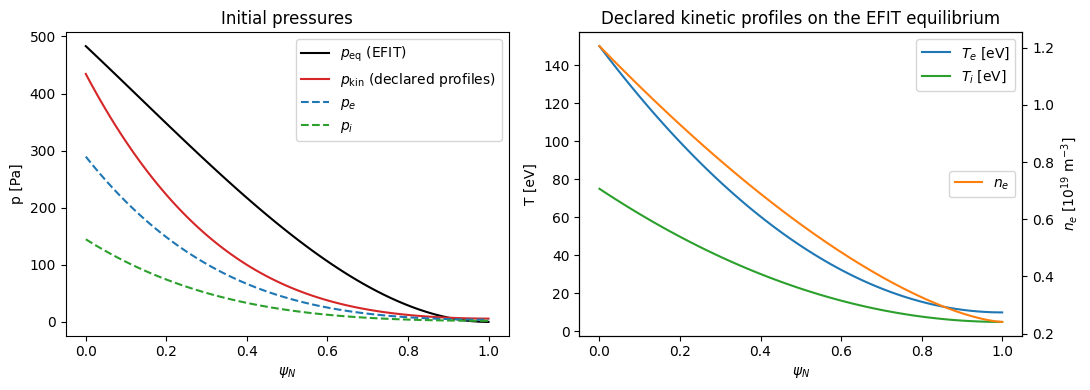

max|p_kin - p_eq| / max p_eq = 0.268;  W_kin/W_eq - 1 = -0.387


In [ ]:
kin0 = generate_synthetic_kinetic_profiles(g0, kinetic, time=TIME)
print(kin0.status, "-", kin0.message)
fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 4))
ax.plot(kin0.psi_norm, kin0.p_eq, "k-", label=r"$p_\mathrm{eq}$ (EFIT)")
ax.plot(kin0.psi_norm, kin0.p_total, "C3-", label=r"$p_\mathrm{kin}$ (declared profiles)")
ax.plot(kin0.psi_norm, kin0.p_e, "C0--", label=r"$p_e$")
ax.plot(kin0.psi_norm, kin0.p_i, "C2--", label=r"$p_i$")
ax.set(xlabel=r"$\psi_N$", ylabel="p [Pa]", title="Initial pressures"); ax.legend()
bx.plot(kin0.psi_norm, kin0.T_e, "C0-", label=r"$T_e$ [eV]")
bx.plot(kin0.psi_norm, kin0.T_i, "C2-", label=r"$T_i$ [eV]")
b2 = bx.twinx(); b2.plot(kin0.psi_norm, kin0.n_e / 1e19, "C1-", label=r"$n_e$")
b2.set_ylabel(r"$n_e$ [$10^{19}$ m$^{-3}$]")
bx.set(xlabel=r"$\psi_N$", ylabel="T [eV]", title="Declared kinetic profiles on the EFIT equilibrium")
bx.legend(loc="upper right"); b2.legend(loc="center right")
fig.tight_layout(); plt.show()
print(f"max|p_kin - p_eq| / max p_eq = {kin0.pressure.max_relative_residual:.3f};  "
      f"W_kin/W_eq - 1 = {kin0.pressure.thermal_energy_relative_difference:+.3f}")

## 2. Mode `equilibrium_pressure`: keep $p_\mathrm{eq}$ and decompose it

When the equilibrium pressure is authoritative, the kinetic spec must close the pressure
(`pressure_constraint="equilibrium"`). Here `closure="temperature"` solves $T_e(\psi)$ so that
$p_\mathrm{kin} = p_\mathrm{eq}$, with $n_e$ and $T_i/T_e$ held. This is the **identity case**:
nothing is re-solved, CHEASE is never called, and the state is consistent after one pass.

In [ ]:
decompose = EquilibriumKineticSpec(
    SyntheticKineticSpec(n_e=kinetic.n_e, temperature=kinetic.temperature,
                         pressure_constraint="equilibrium", closure="temperature"),
    closure="equilibrium_pressure")
eq_mode = build_consistent_state(g0, decompose, workdir=WORK / "equilibrium_pressure", time=TIME)
print(eq_mode.status, "-", eq_mode.message)
print("CHEASE updates:", len(eq_mode.iterations), "| files written:", list((WORK / "equilibrium_pressure").glob("*")))
pd.DataFrame(eq_mode.assumption_table(), columns=["quantity", "role"])

converged - the given equilibrium's pressure is decomposed by the #122 closure 'temperature': max|p_kin - p_eq|/max p_eq = 2.35e-16 up to psi_N = 0.9025; no CHEASE update is requested
CHEASE updates: 0 | files written: []


                                                                     quantity                               role
0  kinetic assumptions (the #122 spec: held channels, T_i route, composition)                               held
1                     the given equilibrium: psi(R,Z), p_eq, q(psi), boundary            held (no CHEASE update)
2                         the channel the closure solves so that p_kin = p_eq  recomputed from the kinetic state
3                                                        n_i, Z_eff, p_e, p_i  recomputed from the kinetic state
4                                                   pressure closure residual                 convergence metric

## 3. Mode `kinetic_pressure`: re-solve the equilibrium for $p_\mathrm{kin}$

Pressure alone does not fix a Grad–Shafranov equilibrium. The non-pressure source is declared
by a `CurrentPolicy`:

- `preserve_ffprime_shape` keeps the **initial** equilibrium's normalized $FF'(\psi_N)$. The shape
  is re-sampled from that one array every update. The amplitude is carried over from the previous
  solve.
- `analytic_ffprime_shape` uses $FF' \propto -dg/d\psi_N$ of a declared analytic profile $g$
  (the #1166 scope-B convention). Section 6 shows it.

CHEASE then imposes one normalization, either $I_p$ (`NCSCAL = 2`, used here) or $q_{95}$
(`NCSCAL = 1`). It rescales $p'$ and $FF'$ together to meet that normalization, so the split of
the current between the two terms is **re-solved**. $q$ is always an output and is never written
after a solve.

Each update is accepted only if it passes these checks: a solution exists, the arrays are finite,
$p \ge 0$, the axis is inside the boundary, CHEASE's own solved boundary lies within 1 % of a
half-width of the `EXPEQ` boundary, the held $I_p$ or $q_{95}$ is met to $10^{-3}$, the $I_p$/$B_0$
orientation is unchanged, and $|F_\mathrm{edge}|$ is held.

Convergence needs **all** of the following: the pressure residual
$\max|p_\mathrm{kin}-p_\mathrm{eq}|/\max p_\mathrm{kin}$ of the *new* equilibrium, the change of
$p_\mathrm{kin}$, $p_\mathrm{eq}$, $n_e$, $T_e$, $T_i$, $n_i$ and $|q|$, the change of the
$\rho_\mathrm{tor}(\psi_N)$ map, the change of $q_0$, $q_{95}$, $l_i$, $\beta_p$ and $W_\mathrm{th}$
(each $\le 10^{-3}$), and an axis change of at most $10^{-4}$ m.

In [ ]:
spec = EquilibriumKineticSpec(kinetic, closure="kinetic_pressure",
                              current_policy=CurrentPolicy("preserve_ffprime_shape", "plasma_current"),
                              convergence=ConvergenceCriteria(max_iterations=10))
if HAVE_CHEASE:
    state = build_consistent_state(g0, spec, config=DEMO_MESH, workdir=WORK / "kinetic_pressure", time=TIME)
    print(state.status, "-", state.message)
    rows = []
    for s in state.states:
        m, c = s.metrics, s.scalars
        rows.append({"state": s.index, "status": s.status,
                     "max|p_kin-p_eq|/max p": m.get("pressure_max_relative"),
                     "W_kin/W_eq-1": m.get("thermal_energy_relative"),
                     "|dp_kin|": m.get("p_kin_change"), "|dp_eq|": m.get("p_eq_change"),
                     "|dq|": m.get("q_change"), "|drho_tor|": m.get("rho_tor_change"),
                     "Ip [kA]": c["ip"] / 1e3, "q0": c["q0"], "q95": c["q95"], "li": c["li"],
                     "beta_p": c["beta_p"], "R_axis [m]": c["magnetic_axis_r"], "W_th [J]": c.get("w_th")})
    history = pd.DataFrame(rows).set_index("state")
    display(history)
else:
    state = None
    print("CHEASE not found: skipping the kinetic_pressure solves.")

converged - every enabled criterion met after 4 update(s): max|p_kin - p_eq|/max p_kin = 9.72e-05


         status  max|p_kin-p_eq|/max p  W_kin/W_eq-1  |dp_kin|   |dp_eq|      |dq|  |drho_tor|  Ip [kA]    q0   q95     li  beta_p  R_axis [m]  W_th [J]
state                                                                                                                                                   
0       initial                 0.2982       -0.3871       NaN       NaN       NaN         NaN    77.04  1.96 8.839 0.6894  0.2708      0.4813     280.2
1      accepted                  0.235       -0.1804   0.06198    0.1553    0.0557     0.03996    77.04 1.235 8.387 0.8185  0.1883      0.4876     193.3
2      accepted               0.002942      0.002162   0.01153    0.2529   0.01591     0.01089    77.04 1.376 8.448 0.7796  0.1563      0.4828     160.4
3      accepted               0.000155    -0.0001468 0.0001599  0.003183 0.0002157   0.0001528    77.04 1.374 8.447 0.7802  0.1566      0.4829     160.7
4      accepted              9.716e-05    -9.759e-05 3.134e-06 6.331e-05 4.246e-06

### Iteration history

State 0 is the EFIT equilibrium. Each later state is one CHEASE update, measured **after** the
solve: the pressure is re-extracted from the solved equilibrium and compared with the kinetic
pressure regenerated on it. CHEASE rescales $p'$ and $FF'$ by one factor to hold $I_p$, and the
solved $FF'$ amplitude is carried into the next input, so that factor contracts to one. The rate
is roughly the pressure-driven share of the current.

The first update does two things at once: it replaces the pressure, and it moves from EFIT's
solution to CHEASE's own solution on the same boundary. After that, the residual falls by more than
an order of magnitude per update until it reaches the interpolation floor near $10^{-4}$.

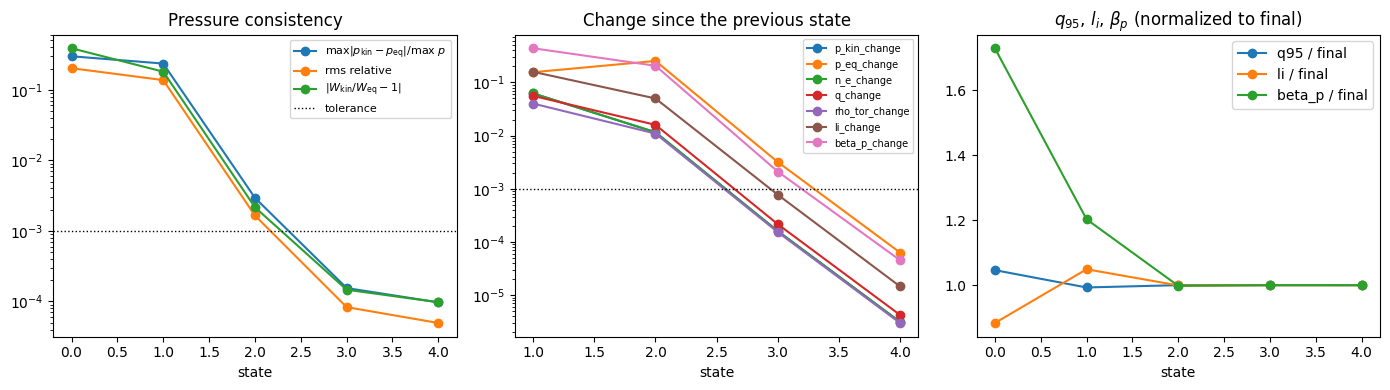

In [ ]:
if state is not None:
    n = np.arange(len(state.states))
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for name, label in (("pressure_max_relative", r"max$|p_\mathrm{kin}-p_\mathrm{eq}|$/max $p$"),
                        ("pressure_rms_relative", "rms relative"),
                        ("thermal_energy_relative", r"$|W_\mathrm{kin}/W_\mathrm{eq}-1|$")):
        axes[0].semilogy(n, np.abs(state.history(name)), "o-", label=label)
    axes[0].axhline(spec.convergence.pressure_rtol, color="k", ls=":", lw=1, label="tolerance")
    axes[0].set(xlabel="state", title="Pressure consistency"); axes[0].legend(fontsize=8)
    for name in ("p_kin_change", "p_eq_change", "n_e_change", "q_change", "rho_tor_change", "li_change",
                 "beta_p_change"):
        axes[1].semilogy(n[1:], np.maximum(state.history(name)[1:], 1e-12), "o-", label=name)
    axes[1].axhline(1e-3, color="k", ls=":", lw=1)
    axes[1].set(xlabel="state", title="Change since the previous state"); axes[1].legend(fontsize=7)
    for name, style in (("q95", "C0o-"), ("li", "C1o-"), ("beta_p", "C2o-")):
        values = state.history(name)
        axes[2].plot(n, values / values[-1], style, label=f"{name} / final")
    axes[2].set(xlabel="state", title=r"$q_{95}$, $l_i$, $\beta_p$ (normalized to final)"); axes[2].legend()
    fig.tight_layout(); plt.show()

### Initial against final

The final pressure is CHEASE's own $p_\mathrm{eq}$, and it lies on top of $p_\mathrm{kin}$.
$q_0$, $q_{95}$, $l_i$ and $\beta_p$ all move (see the table above). Part of that move is the first
step from EFIT's solution to CHEASE's, not the pressure change alone. The volume-averaged density
target is re-applied on each new $V(\psi)$, so $n_e$ is regenerated from the spec rather than
carried over. It ends about 5 % higher than on the EFIT equilibrium, because the traced volume
changed. With pure hydrogen, $n_i = n_e$.

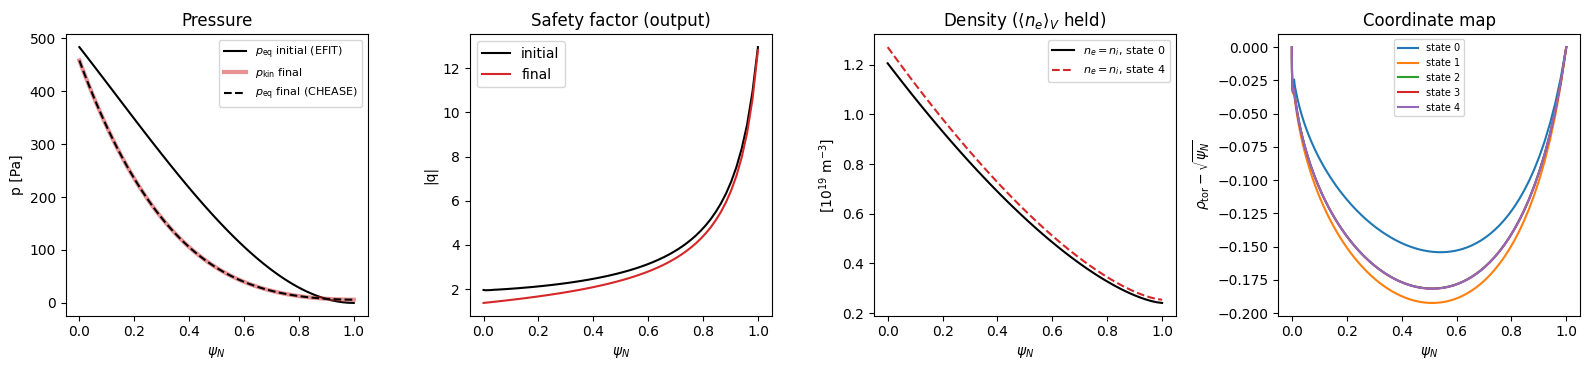

T_e and T_i are declared in psi_N with no normalization, so they are identical in every state: True
rational surfaces, initial: {'q=2': 0.08068616094900097, 'q=3': 0.5697456268540525, 'q=4': 0.7316696365032015}  final: {'q=1.5': 0.09198607863590198, 'q=2': 0.3639153460225809, 'q=3': 0.6388417889277919, 'q=4': 0.76714938193065}


In [ ]:
if state is not None:
    first, last = state.initial, state.final
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
    axes[0].plot(first.psi_norm, first.p_eq, "k-", label=r"$p_\mathrm{eq}$ initial (EFIT)")
    axes[0].plot(last.psi_norm, last.p_kin, "C3-", lw=3, alpha=0.5, label=r"$p_\mathrm{kin}$ final")
    axes[0].plot(last.psi_norm, last.p_eq, "k--", label=r"$p_\mathrm{eq}$ final (CHEASE)")
    axes[0].set(xlabel=r"$\psi_N$", ylabel="p [Pa]", title="Pressure"); axes[0].legend(fontsize=8)
    axes[1].plot(first.psi_norm, first.q, "k-", label="initial"); axes[1].plot(last.psi_norm, last.q, "C3-", label="final")
    axes[1].set(xlabel=r"$\psi_N$", ylabel="|q|", title="Safety factor (output)"); axes[1].legend()
    for s, style in ((first, "k-"), (last, "C3--")):
        axes[2].plot(s.psi_norm, s.kinetic.n_e / 1e19, style, label=rf"$n_e = n_i$, state {s.index}")
    axes[2].set(xlabel=r"$\psi_N$", ylabel=r"[$10^{19}$ m$^{-3}$]", title=r"Density ($\langle n_e\rangle_V$ held)")
    axes[2].legend(fontsize=8)
    for s in state.states:
        axes[3].plot(s.psi_norm, s.rho_tor_norm - np.sqrt(s.psi_norm), label=f"state {s.index}")
    axes[3].set(xlabel=r"$\psi_N$", ylabel=r"$\rho_\mathrm{tor} - \sqrt{\psi_N}$", title="Coordinate map")
    axes[3].legend(fontsize=7)
    fig.tight_layout(); plt.show()
    print("T_e and T_i are declared in psi_N with no normalization, so they are identical in every state:",
          np.array_equal(first.kinetic.T_e, last.kinetic.T_e))
    print("rational surfaces, initial:", dict(first.rational_surfaces), " final:", dict(last.rational_surfaces))

## 4. What was assumed, what was recomputed, what was held

The table below comes from the result. It lists what the iteration held, what it recomputed
from the kinetic state, what CHEASE recomputed, what is a numerical control and what is a
convergence metric. The CHEASE settings that the workflow fixes regardless of the caller's
config are recorded in the provenance.

In [ ]:
if state is not None:
    display(pd.DataFrame(state.assumption_table(), columns=["quantity", "role"]))
    print(pd.Series(dict(state.policy)).to_string())
    print()
    for key, why in state.provenance["chease_fixed_settings"].items():
        print(f"{key:28s} {why}")
    print("\npressure source:", state.iterations[0].pressure_source.method)
    print("round trip p -> p' -> p (max relative):",
          max(s.pressure_source.roundtrip_max_relative for s in state.iterations))

                                                                        quantity                                 role
0   kinetic assumptions (the #122 spec: shapes, targets, T_i route, composition)                                 held
1              fixed boundary (the initial equilibrium's RBBBS, target_psin = 1)                                 held
2                                                    vacuum field F_edge = R0 B0                                 held
3                         normalized FF'(psi_N) shape of the initial equilibrium                                 held
4              plasma current I_p of the initial equilibrium (CHEASE NCSCAL = 2)                                 held
5                                     p_kin, p_e, p_i, n_e, T_e, T_i, n_i, Z_eff    recomputed from the kinetic state
6                                               PRES and PPRIME handed to CHEASE    recomputed from the kinetic state
7                psi(R,Z), p_eq, q(psi), FF' amplitude, 

kind                                                                            preserve_ffprime_shape
normalization                                                                           plasma_current
ncscal                                                                                               2
held_target                                                                                  7.704e+04
held_target_unit                                                                                     A
current_profile                                                                                   None
held_shape                                      normalized FF'(psi_N) shape of the initial equilibrium
held_normalization                                       plasma current I_p of the initial equilibrium
chease_ncscal                                                                                        2
re_solved                    FF' amplitude, psi(R,Z), q95, q0 and q(psi),

## 5. The output: one ODS with `equilibrium` and `core_profiles`

The final accepted state is written as the CHEASE equilibrium together with the #122
`core_profiles` slice from the same state, and both are labelled as assumption-driven.

In [ ]:
if state is not None:
    ods = state.ods
    print("equilibrium.code.name       :", ods["equilibrium.code.name"])
    print("equilibrium comment         :", ods["equilibrium.ids_properties.comment"])
    print("core_profiles.code.name     :", ods["core_profiles.code.name"])
    print("core_profiles comment       :", ods["core_profiles.ids_properties.comment"])
    print("time (equilibrium, profiles):", ods["equilibrium.time"], ods["core_profiles.time"])
    print("state basis                 :", state.provenance["state_basis"],
          "| transport_predicted =", state.provenance["transport_predicted"],
          "| reconstructed =", state.provenance["reconstructed"])
    print("CHEASE work directories     :", [s.chease_workdir.name for s in state.iterations])

equilibrium.code.name       : vaft.code.chease_kinetic_iteration
equilibrium comment         : Assumption-driven self-consistent equilibrium/kinetic state (vaft #123): a CHEASE fixed-boundary equilibrium re-solved for the pressure of declared synthetic kinetic profiles; not transport-predicted, not reconstructed from measurements.
core_profiles.code.name     : vaft.process.profile.generate_synthetic_kinetic_profiles
core_profiles comment       : Synthetic, assumption-driven kinetic profiles generated from a magnetic equilibrium (vaft #122); not measured, not fitted, not transport-predicted.
time (equilibrium, profiles): [0.319] [0.319]
state basis                 : assumption-driven self-consistent | transport_predicted = False | reconstructed = False
CHEASE work directories     : ['iteration_01', 'iteration_02', 'iteration_03', 'iteration_04']


## 6. A declared analytic current profile, and a $q_{95}$ normalization

The same kinetic spec is used with two different non-pressure policies:

- $FF' \propto -dg/d\psi_N$ for a declared $g(\psi_N)$, holding $I_p$;
- the initial $FF'$ shape, holding $q_{95}$ instead of $I_p$.

Every policy reaches a consistent state, but not the same one. The current profile is an
assumption in the same way the kinetic profiles are.

                                status updates final residual        ip     q0   q95     li beta_p
initial FF' shape, Ip held   converged       4      9.716e-05 7.704e+04  1.374 8.447 0.7802 0.1566
analytic g, Ip held          converged       4      8.547e-05 7.704e+04 0.9944 8.012 0.9827 0.1472
initial FF' shape, q95 held  converged       4      0.0001039 7.339e+04  1.367  8.84 0.7961 0.1715

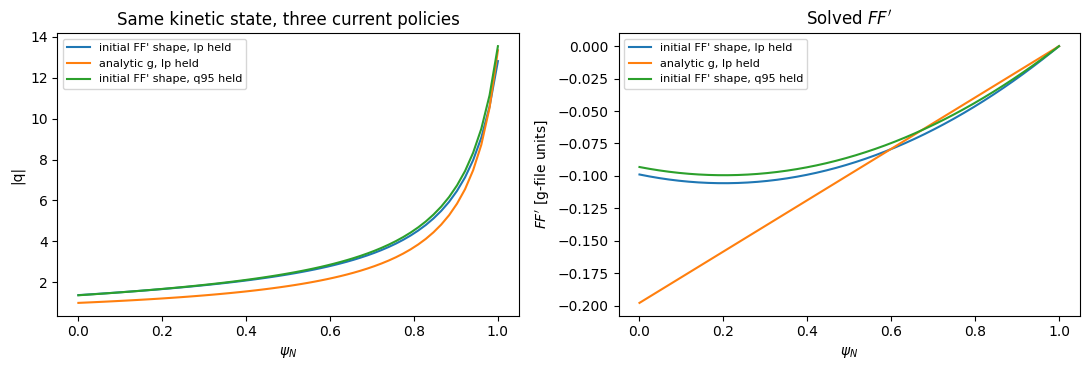

In [ ]:
if HAVE_CHEASE:
    g_current = compose_analytic_profile("g", unit="", axis_value=1.0, separatrix_value=0.01, core_beta=2.0)
    variants = {
        "initial FF' shape, Ip held": state,
        "analytic g, Ip held": build_consistent_state(
            g0, EquilibriumKineticSpec(kinetic, current_policy=CurrentPolicy("analytic_ffprime_shape",
                                                                             current_profile=g_current)),
            config=DEMO_MESH, workdir=WORK / "analytic_current", time=TIME),
        "initial FF' shape, q95 held": build_consistent_state(
            g0, EquilibriumKineticSpec(kinetic, current_policy=CurrentPolicy(normalization="q95")),
            config=DEMO_MESH, workdir=WORK / "q95", time=TIME),
    }
    table = pd.DataFrame({label: {"status": v.status, "updates": len(v.iterations),
                                  "final residual": v.final.metrics["pressure_max_relative"],
                                  **{k: v.final.scalars[k] for k in ("ip", "q0", "q95", "li", "beta_p")}}
                          for label, v in variants.items()}).T
    display(table)
    fig, (ax, bx) = plt.subplots(1, 2, figsize=(11, 3.8))
    for label, v in variants.items():
        ax.plot(v.final.psi_norm, v.final.q, label=label)
        g = v.final.equilibrium
        bx.plot(np.linspace(0, 1, int(g["NW"])), np.asarray(g["FFPRIM"]), label=label)
    ax.set(xlabel=r"$\psi_N$", ylabel="|q|", title="Same kinetic state, three current policies"); ax.legend(fontsize=8)
    bx.set(xlabel=r"$\psi_N$", ylabel=r"$FF'$ [g-file units]", title=r"Solved $FF'$"); bx.legend(fontsize=8)
    fig.tight_layout(); plt.show()
else:
    print("CHEASE not found: skipping.")

## 7. Failure and non-convergence are states, not exceptions

- A **hollow** kinetic pressure has a $p'$ that changes sign. The adapter's `EXPEQ` carries $-|p'|$,
  so such a pressure cannot be handed to CHEASE faithfully. It is refused before any solve, with the
  status `invalid_pressure_source`.
- A **cap too small** for the tolerances ends as `max_iterations`. The last accepted pair is still
  written, and the unmet criteria are named.

The other states are `chease_failed` (no solution, a timeout, or no executable), `validation_failed`
(a solution that fails a check), `kinetic_generation_failed` (#122 refuses the spec on the new
equilibrium), `diverged`, `oscillating` and `stagnated`. All of them are tested offline in
`test/test_equilibrium_kinetic_iteration.py`, and every state keeps its diagnostics.

In [ ]:
hollow_T_e = TabulatedProfile(np.array([0.0, 0.5, 1.0]), np.array([60.0, 200.0, 20.0]),
                              coordinate="psi_norm", unit="eV")
hollow = EquilibriumKineticSpec(SyntheticKineticSpec(n_e=kinetic.n_e, T_e=ProfileSpec(hollow_T_e),
                                                     temperature=kinetic.temperature, pressure_constraint="kinetic"))
refused = build_consistent_state(g0, hollow, config=DEMO_MESH, workdir=WORK / "hollow", time=TIME)
print(refused.status, "-", refused.message)
print("CHEASE work directories created:", sorted(p.name for p in (WORK / "hollow").glob("iteration_*")))

if HAVE_CHEASE:
    capped = build_consistent_state(g0, EquilibriumKineticSpec(kinetic, convergence=ConvergenceCriteria(max_iterations=2)),
                                    config=DEMO_MESH, workdir=WORK / "capped", time=TIME)
    print(capped.status, "-", capped.message)
    print("final state:", capped.final.index, "| ODS written:", capped.ods is not None)

invalid_pressure_source - the kinetic pressure rises outward near psi_N = 0.000; CHEASE's EXPEQ carries p' of one sign (the adapter writes -|p'|), so a hollow pressure cannot be handed to it faithfully
CHEASE work directories created: []


max_iterations - 2 updates without meeting every criterion; unmet: pressure_rtol, profile_rtol, q_rtol, coordinate_atol, scalar_rtol, axis_atol
final state: 2 | ODS written: True


## Scope and limitations

- **Mixed or partial closures** are not implemented. Examples are holding only an integral, only a
  pressure partition, or only a profile region.
- **Restart** works from an in-memory result (`resume=`). There is no serialized checkpoint format.
- The **current policy** is an assumption. Section 6 shows that each policy converges to a
  different consistent state. None of them is a prediction of the current profile.
- The **resolution sensitivity** of the converged state (kinetic grid, CHEASE `NS`/`NT`) is not
  studied here. This notebook uses a demo mesh.